# AdvectNet — Prototype Notebook
### PS12: Enhancing the temporal resolution of satellite imagery

**The problem.** Geostationary weather satellites such as India's INSAT-3DS image the country only **once every 30 minutes** — too slow to smoothly follow cyclones, thunderstorms and fast-moving clouds. This prototype shows we can **synthesise the missing in-between frames with AI**: given the images at time *t* and *t + 30 min*, predict the images at *t + 10* and *t + 20*.

Built and validated on **free Himawari-9 data** over **eastern India / Bay of Bengal** (Himawari sees this region; INSAT-3DS is the eventual deployment target).

## Architecture of the prototype (what is actually implemented)

A **warp-based, time-conditioned interpolator**. The core idea: do **not** average the two frames (averaging blurs and ghosts) — instead estimate how the clouds **move**, **warp the real pixels** to the in-between time, then let a small network repair whatever warping cannot.

    frame t ────┐                                   ┌─► warp real pixels to t+Δ ─┐
                ├─► RAFT optical flow ─► intermediate flow                       ├─► small U-Net ─► prediction
    frame t+30 ─┘       (frozen)        (Super-SloMo approx)                     │   (blend mask + residual)
                                                                                 │
        time fraction α  (1/3 → t+10,  2/3 → t+20) ──────────────────────────────┘

**Step by step**
1. **Data** — Himawari-9 Band-13 (10.4 µm thermal IR) → calibrate to **brightness temperature (Kelvin)** → normalise to 0–1 → cut into 256×256 patches. Each sample = inputs (t, t+30), targets (t+10, t+20).
2. **Motion** — a **pretrained, frozen RAFT** network estimates the optical flow between t and t+30 in both directions.
3. **Intermediate flow** — a Super-SloMo approximation turns those into the flow from the in-between time back to each input frame.
4. **Warp** — backward-warp the two real frames to the in-between time → two sharp candidate images.
5. **Synthesis** — a **small time-conditioned U-Net** outputs a blend **mask** and a **residual** correction:
   prediction = mask × warp(t) + (1 − mask) × warp(t+30) + residual.
6. **Loss** — Charbonnier (robust L1) + edge/gradient term + **advection consistency** (∂θ/∂t + u·∇θ ≈ 0) + **sparse source prior** (‖residual‖₁).
7. **Evaluation** — SSIM / PSNR / MSE against a **linear-blend baseline**, reported overall **and** on the highest-motion patches (where interpolation is hardest).

## What is deliberately NOT in this prototype (= headroom for the full system)
- ~~physics-informed advection / source regulariser~~ **→ now integrated**
- quadratic (accelerating) motion estimated from 4 frames
- attention bottleneck inside the U-Net
- perceptual loss and RAFT fine-tuning

These are the planned upgrades. The prototype already beats the baseline **without** them.

## Validated result
On Himawari-9 over eastern India (2024-06-15): the model beats linear blending on every metric, and the **gain roughly doubles on high-motion scenes** (SSIM 0.70 → 0.85, PSNR +4.3 dB) — confirming that warping wins precisely where clouds move.

## How to run
Turn on the GPU (**Settings ▸ Accelerator ▸ GPU**), then run the cells top to bottom. The data cell takes ~20–30 min (it downloads ~50 frames).

## Cell 1 — Setup
Installs the libraries and removes the Kaggle image's broken **cartopy** (it crashes satpy on import; we never use it).

In [1]:
# ===== Setup =====
# satpy reads Himawari; torch/torchvision run the model.
# The Kaggle GPU image ships a broken `cartopy` that crashes satpy on import -> remove it.
!pip install -q s3fs satpy scikit-image imageio
!pip uninstall -y -q cartopy

import torch
print("Torch:", torch.__version__, "| GPU available:", torch.cuda.is_available())
print("If GPU is False -> Settings > Accelerator > GPU (T4), then rerun.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 30.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 82.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.8/484.8 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.4/680.4 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.6/95.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 100.8 MB/s eta 0:00:0000:0100:01
Torch: 2.10.0+cu128 | GPU available: True
If GPU is False -> Settings > Accelerator > GPU (T4), then rerun.


## Cell 2 — Build the dataset
Downloads consecutive 10-minute Himawari frames over eastern India, converts each to **brightness temperature**, and tiles them into 256×256 **quadruplet** patches: inputs (t, t+30) and targets (t+10, t+20). Saves one compressed file, **advectnet_dataset.npz**.

*Tip: set N_FRAMES = 8 for a ~2-minute trial, then 50 for the full set.*

In [2]:
# ===== 1. Build the dataset =====
# Each TRAINING SAMPLE (a "quadruplet" from 4 consecutive frames):
#   inputs : frame[t] and frame[t+30min]
#   targets: frame[t+10min] and frame[t+20min]   <- what the model must predict
import os, bz2, shutil, datetime as dt
import numpy as np, s3fs
from satpy import Scene

BUCKET, PRODUCT, BAND = "noaa-himawari9", "AHI-L1b-FLDK", "B13"
START      = dt.datetime(2024, 6, 15, 0, 0)   # UTC start time
N_FRAMES   = 50                                # 8 = quick trial; 50 = full set
STEP_MIN   = 10
INDIA_BBOX = (82.0, 8.0, 100.0, 26.0)          # min_lon, min_lat, max_lon, max_lat
PATCH, STRIDE = 256, 192
BT_MIN, BT_MAX = 180.0, 310.0                   # Kelvin range for normalization
MAX_INVALID = 0.20
TMP, OUT = "hima_tmp", "advectnet_dataset.npz"

fs = s3fs.S3FileSystem(anon=True)               # public bucket, no account needed

def load_frame(dtobj):
    """Download one timestamp -> (normalized BT India crop, validity mask)."""
    prefix = f"{BUCKET}/{PRODUCT}/{dtobj:%Y/%m/%d/%H%M}/"
    try:
        files = sorted(f for f in fs.ls(prefix) if f"_{BAND}_" in f)
    except Exception:
        return None, None
    if len(files) < 10:
        return None, None
    os.makedirs(TMP, exist_ok=True)
    paths = []
    try:
        for key in files:                                    # 10 full-disk segments
            out = os.path.join(TMP, os.path.basename(key)[:-4])
            with fs.open(key, "rb") as s:
                open(out, "wb").write(bz2.decompress(s.read()))
            paths.append(out)
        scn = Scene(reader="ahi_hsd", filenames=paths)        # satpy reads HSD format
        scn.load([BAND], calibration="brightness_temperature")
        bt = np.asarray(scn.crop(ll_bbox=INDIA_BBOX)[BAND].values, dtype=np.float32)
    except Exception as e:
        print("   ! read failed @", dtobj, e)
        return None, None
    finally:
        shutil.rmtree(TMP, ignore_errors=True)                # keep disk clean
    valid = np.isfinite(bt)
    norm = (np.clip(bt, BT_MIN, BT_MAX) - BT_MIN) / (BT_MAX - BT_MIN)
    return np.where(valid, norm, 0.0).astype(np.float32), valid

# --- fetch consecutive frames ---
frames, masks, times, target_shape = [], [], [], None
for k in range(N_FRAMES):
    t = START + dt.timedelta(minutes=STEP_MIN * k)
    norm, valid = load_frame(t)
    times.append(t)
    if norm is None:
        print(f"[{k+1}/{N_FRAMES}] {t:%H:%M} missing -> skip")
        frames.append(None); masks.append(None); continue
    if target_shape is None:
        target_shape = norm.shape
    if norm.shape[0] < target_shape[0] or norm.shape[1] < target_shape[1]:
        frames.append(None); masks.append(None); continue
    H, W = target_shape
    frames.append(norm[:H, :W]); masks.append(valid[:H, :W])
    print(f"[{k+1}/{N_FRAMES}] {t:%H:%M} ok")

assert target_shape is not None, "No frames loaded -- check START / Internet ON."

# --- tile consecutive 4-frame windows into patch quadruplets ---
H, W = target_shape
ys = range(0, H - PATCH + 1, STRIDE)
xs = range(0, W - PATCH + 1, STRIDE)
X0, X3, Y1, Y2 = [], [], [], []
for i in range(len(frames) - 3):
    quad, mq = frames[i:i+4], masks[i:i+4]
    if any(f is None for f in quad):
        continue
    for y in ys:
        for x in xs:
            sl = (slice(y, y+PATCH), slice(x, x+PATCH))
            if 1.0 - (mq[0][sl] & mq[1][sl] & mq[2][sl] & mq[3][sl]).mean() > MAX_INVALID:
                continue
            X0.append(quad[0][sl]); Y1.append(quad[1][sl])
            Y2.append(quad[2][sl]); X3.append(quad[3][sl])

X0 = np.asarray(X0, np.float16); X3 = np.asarray(X3, np.float16)
Y1 = np.asarray(Y1, np.float16); Y2 = np.asarray(Y2, np.float16)
print("\nQuadruplet patches:", len(X0))
np.savez_compressed(OUT, X0=X0, X3=X3, Y1=Y1, Y2=Y2,
                    bt_min=BT_MIN, bt_max=BT_MAX, patch=PATCH, bbox=np.array(INDIA_BBOX))
print("saved", OUT, f"({os.path.getsize(OUT)/1e6:.0f} MB)  DONE")

/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


[1/50] 00:00 ok


/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


[2/50] 00:10 ok


/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


...

[48/50] 07:50 ok


/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


[49/50] 08:00 ok


/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)


[50/50] 08:10 ok

Quadruplet patches: 516
saved advectnet_dataset.npz (179 MB)  DONE


## Cell 3 — Baseline + metrics
Defines the SSIM / PSNR / MSE metrics and a fixed train/val split (reused later), then scores the naive **linear-blend** baseline — the number the model must beat.

In [3]:
# ===== 2. Baseline + metrics =====
import numpy as np, matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim_fn

d  = np.load("advectnet_dataset.npz", allow_pickle=True)
X0 = d["X0"].astype(np.float32); X3 = d["X3"].astype(np.float32)
Y1 = d["Y1"].astype(np.float32); Y2 = d["Y2"].astype(np.float32)
print("patches:", X0.shape)

# fixed train/val split (reused by the model + eval cells via the same seed)
rng = np.random.default_rng(0); perm = rng.permutation(len(X0))
n_val = max(1, int(0.15 * len(X0)))
val_idx, train_idx = perm[:n_val], perm[n_val:]
print("train/val:", len(train_idx), len(val_idx))

def eval_metrics(pred, gt):
    pred = np.clip(pred, 0, 1); gt = np.clip(gt, 0, 1)
    mse  = np.mean((pred - gt) ** 2, axis=(1, 2))
    psnr = 10 * np.log10(1.0 / np.clip(mse, 1e-12, None))
    ssim = np.array([ssim_fn(p, g, data_range=1.0) for p, g in zip(pred, gt)])
    return mse.mean(), psnr.mean(), ssim.mean()

# linear-interp baselines at the right time fractions (1/3 -> t+10, 2/3 -> t+20)
b1 = (2/3)*X0 + (1/3)*X3
b2 = (1/3)*X0 + (2/3)*X3
m1 = eval_metrics(b1[val_idx], Y1[val_idx]); m2 = eval_metrics(b2[val_idx], Y2[val_idx])
print(f"\nBASELINE val  t+10  SSIM {m1[2]:.4f} | PSNR {m1[1]:.2f} | MSE {m1[0]:.5f}")
print(f"BASELINE val  t+20  SSIM {m2[2]:.4f} | PSNR {m2[1]:.2f} | MSE {m2[0]:.5f}")

patches: (516, 256, 256)
train/val: 439 77

BASELINE val  t+10  SSIM 0.7993 | PSNR 29.70 | MSE 0.00137
BASELINE val  t+20  SSIM 0.7976 | PSNR 29.64 | MSE 0.00139


## Cell 4 — The model + training
Loads frozen **RAFT** for optical flow, defines the time-conditioned U-Net, and trains it with **three loss terms**:

| Loss | Formula | Purpose |
|------|---------|--------|
| Charbonnier reconstruction | `√((ŷ−y)²+ε²)` | Robust pixel fidelity |
| Gradient / edge | `|∇ŷ−∇y|` | Preserve cloud boundary sharpness |
| **Advection consistency** *(new)* | `‖(ŷ−x₀) + F_{t→0}·∇ŷ‖₁` | Enforce atmospheric transport physics |
| **Sparse source prior** *(new)* | `‖residual‖₁` | Most prediction must come from warping, not the catch-all residual |

The advection loss is derived from the scalar advection PDE:

$$\frac{\partial \theta}{\partial t} + \mathbf{u}\cdot\nabla\theta = S$$

where **u** = optical flow (F_{t→0}), θ = brightness temperature, S = source term (ideally sparse). Penalising deviations from this equation in smooth regions anchors the network's intermediate frames to physical cloud motion.

In [ ]:
# ===== 3. Model: RAFT flow + warp + time-conditioned U-Net =====
# ── What is NEW vs the prototype ──────────────────────────────────────────────
#  1. Advection consistency loss  L_adv = ||(ŷ - x0) + F_{t→0}·∇ŷ||_1
#     Derived from ∂θ/∂t + u·∇θ = S (scalar advection PDE).
#     Forces in-between frames to be physically reachable from frame-0 by the
#     estimated flow. λ_adv = 0.15 (moderate; does not overwhelm reconstruction).
#  2. Sparse source prior  L_src = ||residual||_1
#     The residual head should handle cloud formation/dissipation, NOT act as a
#     free compensator for bad flows. An L1 penalty keeps it physically honest.
#     λ_src = 0.05.
#  Everything else (RAFT frozen, Super-SloMo flow approx, U-Net, Charbonnier,
#  gradient loss) is unchanged from the prototype.
# ──────────────────────────────────────────────────────────────────────────────
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torchvision.models.optical_flow import raft_small, Raft_Small_Weights

dev = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", dev)

# data + same fixed split (identical seed to baseline cell)
d = np.load("advectnet_dataset.npz", allow_pickle=True)
X0, X3, Y1, Y2 = (d[k].astype(np.float32) for k in ["X0", "X3", "Y1", "Y2"])
N, H, W = X0.shape
rng = np.random.default_rng(0); perm = rng.permutation(N); nv = max(1, int(0.15 * N))
val_idx, train_idx = perm[:nv], perm[nv:]

# ── RAFT optical flow (pretrained, FROZEN) ────────────────────────────────────
raft = raft_small(weights=Raft_Small_Weights.DEFAULT).to(dev).eval()
for p in raft.parameters(): p.requires_grad_(False)

def raft_flow(a, b):                          # a,b: [B,1,H,W] in [0,1]
    a3 = (a*2-1).repeat(1,3,1,1); b3 = (b*2-1).repeat(1,3,1,1)
    return raft(a3, b3)[-1]                    # [B,2,H,W] pixels

def backwarp(img, flow):                       # backward warp via bilinear sampling
    B, C, h, w = img.shape
    yy, xx = torch.meshgrid(torch.arange(h, device=img.device),
                             torch.arange(w, device=img.device), indexing="ij")
    grid = torch.stack((xx, yy), 0).float()[None].repeat(B, 1, 1, 1) + flow
    gx = 2*grid[:, 0]/(w-1) - 1; gy = 2*grid[:, 1]/(h-1) - 1
    return F.grid_sample(img, torch.stack((gx, gy), -1), mode="bilinear",
                         padding_mode="border", align_corners=True)

def inter_flows(F03, F30, a):                  # Super-SloMo linear flow approx
    Ft0 = -(1-a)*a*F03 + a*a*F30
    Ft3 = (1-a)**2*F03 - a*(1-a)*F30
    return Ft0, Ft3

# ── Precompute all flows once (RAFT frozen → big speedup) ────────────────────
@torch.no_grad()
def precompute(bs=8):
    F03 = np.zeros((N,2,H,W), np.float16); F30 = np.zeros((N,2,H,W), np.float16)
    for s in range(0, N, bs):
        a = torch.tensor(X0[s:s+bs])[:,None].to(dev)
        b = torch.tensor(X3[s:s+bs])[:,None].to(dev)
        F03[s:s+bs] = raft_flow(a, b).half().cpu().numpy()
        F30[s:s+bs] = raft_flow(b, a).half().cpu().numpy()
    return F03, F30
print("precomputing optical flow ..."); F03, F30 = precompute()

# ── U-Net (unchanged architecture) ───────────────────────────────────────────
def cbr(i, o): return nn.Sequential(nn.Conv2d(i, o, 3, 1, 1), nn.GroupNorm(8, o), nn.GELU())
class UNet(nn.Module):
    def __init__(s, ic=8, b=32):
        super().__init__()
        s.e1 = nn.Sequential(cbr(ic, b), cbr(b, b))
        s.e2 = nn.Sequential(cbr(b, 2*b), cbr(2*b, 2*b))
        s.e3 = nn.Sequential(cbr(2*b, 4*b), cbr(4*b, 4*b))
        s.pool = nn.MaxPool2d(2)
        s.d2 = nn.Sequential(cbr(4*b+2*b, 2*b), cbr(2*b, 2*b))
        s.d1 = nn.Sequential(cbr(2*b+b, b), cbr(b, b))
        s.out = nn.Conv2d(b, 2, 3, 1, 1)
    def forward(s, x):
        e1 = s.e1(x); e2 = s.e2(s.pool(e1)); e3 = s.e3(s.pool(e2))
        up = lambda z: F.interpolate(z, scale_factor=2, mode="bilinear", align_corners=False)
        d2 = s.d2(torch.cat([up(e3), e2], 1)); d1 = s.d1(torch.cat([up(d2), e1], 1))
        o = s.out(d1)
        return torch.sigmoid(o[:, 0:1]), torch.tanh(o[:, 1:2])
unet = UNet().to(dev)

# ── Forward pass (unchanged) ──────────────────────────────────────────────────
def model_forward(X0b, X3b, F03b, F30b, a):
    Ft0, Ft3 = inter_flows(F03b, F30b, a)
    w0 = backwarp(X0b, Ft0); w3 = backwarp(X3b, Ft3)
    blend = (1-a)*X0b + a*X3b
    ach = a.expand(-1, 1, H, W)
    mask, res = unet(torch.cat([w0, w3, Ft0, Ft3, blend, ach], 1))
    pred = mask*w0 + (1-mask)*w3 + res
    return pred, w0, w3, blend, Ft0, res      # return Ft0, res for physics losses

# ── Standard losses (unchanged) ───────────────────────────────────────────────
def charb(x, y, eps=1e-3):
    return torch.sqrt((x-y)**2 + eps**2).mean()

def gloss(x, y):
    return (((x[..., 1:]-x[..., :-1]).abs() - (y[..., 1:]-y[..., :-1]).abs()).abs().mean()
          + ((x[..., 1:,:]-x[..., :-1,:]).abs() - (y[..., 1:,:]-y[..., :-1,:]
             ).abs()).abs().mean())

# ── NEW: Physics-guided losses ────────────────────────────────────────────────
def spatial_gradient(x):
    """Compute ∂x/∂col and ∂x/∂row via finite differences. Returns (dx, dy) each [B,1,H,W]."""
    # pad so output stays same spatial size
    dx = F.pad(x[..., 1:] - x[..., :-1], (0, 1))      # ∂/∂x  (column direction)
    dy = F.pad(x[..., 1:, :] - x[..., :-1, :], (0, 0, 0, 1))  # ∂/∂y  (row direction)
    return dx, dy

def advection_loss(pred, x0, Ft0, eps=1e-3):
    """
    Advection consistency: (pred - x0)/Δt + u·∇pred ≈ 0
    With Δt normalised to 1 and u = Ft0 (flow from pred-time to frame-0, i.e. ≈ -wind):
        residual_adv = (pred - x0) + Ft0[:,0:1]*∂pred/∂x + Ft0[:,1:2]*∂pred/∂y
    We use Charbonnier on this residual (robust to cloud edges where PDE breaks down).
    """
    dpx, dpy = spatial_gradient(pred)
    # Ft0: [B,2,H,W] — channel 0 = x-component, channel 1 = y-component
    adv = (pred - x0) + Ft0[:, 0:1] * dpx + Ft0[:, 1:2] * dpy
    return torch.sqrt(adv**2 + eps**2).mean()

def sparse_source_loss(res):
    """
    L1 sparsity prior on the residual (source term S in ∂θ/∂t + u·∇θ = S).
    Encourages most of the prediction to come from physical advection (warping),
    not the free-form residual compensator.
    """
    return res.abs().mean()

# ── Loss weights ──────────────────────────────────────────────────────────────
LAMBDA_CHARB = 1.0    # reconstruction (unchanged)
LAMBDA_GRAD  = 0.5    # edge / gradient (unchanged)
LAMBDA_ADV   = 0.15   # advection PDE consistency (new)
LAMBDA_SRC   = 0.05   # sparse source prior (new)

# ── Training ──────────────────────────────────────────────────────────────────
opt = torch.optim.Adam(unet.parameters(), 5e-4)
scaler = torch.cuda.amp.GradScaler(enabled=(dev == "cuda"))
EPOCHS, BS = 50, 8
ti = np.array(train_idx)

print("\nLoss components: Charbonnier + Gradient + Advection (PDE) + Sparse source")
print(f"  λ_charb={LAMBDA_CHARB}  λ_grad={LAMBDA_GRAD}  λ_adv={LAMBDA_ADV}  λ_src={LAMBDA_SRC}\n")

for ep in range(EPOCHS):
    np.random.shuffle(ti); tot = tot_adv = tot_src = nb = 0; unet.train()
    for s in range(0, len(ti), BS):
        idx = ti[s:s+BS]
        ch = np.random.rand(len(idx)) < 0.5          # half t+10, half t+20
        a_np = np.where(ch, 1/3, 2/3).astype(np.float32)
        tgt = np.where(ch[:, None, None], Y1[idx], Y2[idx]).astype(np.float32)

        X0b  = torch.tensor(X0[idx])[:, None].to(dev)
        X3b  = torch.tensor(X3[idx])[:, None].to(dev)
        F03b = torch.tensor(F03[idx].astype(np.float32)).to(dev)
        F30b = torch.tensor(F30[idx].astype(np.float32)).to(dev)
        a    = torch.tensor(a_np).view(-1, 1, 1, 1).to(dev)
        y    = torch.tensor(tgt)[:, None].to(dev)

        opt.zero_grad()
        with torch.cuda.amp.autocast(enabled=(dev == "cuda")):
            pred, w0, w3, blend, Ft0, res = model_forward(X0b, X3b, F03b, F30b, a)

            l_charb = LAMBDA_CHARB * charb(pred, y)
            l_grad  = LAMBDA_GRAD  * gloss(pred, y)
            l_adv   = LAMBDA_ADV   * advection_loss(pred, X0b, Ft0)
            l_src   = LAMBDA_SRC   * sparse_source_loss(res)
            loss    = l_charb + l_grad + l_adv + l_src

        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        tot     += loss.item()
        tot_adv += l_adv.item()
        tot_src += l_src.item()
        nb += 1

    if (ep+1) % 5 == 0 or ep == 0:
        print(f"epoch {ep+1:>3}/{EPOCHS}  total {tot/nb:.4f}  "
              f"[adv {tot_adv/nb:.4f}  src {tot_src/nb:.4f}]")
print("TRAINING DONE")


## Cell 4B ? Himawari validation MSE

Runs the trained model on the held-out Himawari validation split and reports direct reconstruction errors against the actual intermediate frames: generated `t+10` vs `Y1`, and generated `t+20` vs `Y2`. This is the clean validation loss/error view independent of the showpiece animation.

In [ ]:
# ===== 3B. Validation: generated vs actual Himawari t+10 / t+20 MSE =====
# Run this after Cell 4 finishes training. It uses the same val_idx split and the trained unet.
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

VAL_BS = 16
VAL_OUT_DIR = "advectnet_himawari_validation"
os.makedirs(VAL_OUT_DIR, exist_ok=True)

@torch.no_grad()
def predict_validation(alpha, bs=VAL_BS):
    """Predict all validation patches at temporal fraction alpha."""
    unet.eval()
    pred = np.zeros((len(val_idx), H, W), np.float32)
    for s in range(0, len(val_idx), bs):
        ids = val_idx[s:s+bs]
        X0b  = torch.tensor(X0[ids], dtype=torch.float32, device=dev)[:, None]
        X3b  = torch.tensor(X3[ids], dtype=torch.float32, device=dev)[:, None]
        F03b = torch.tensor(F03[ids].astype(np.float32), dtype=torch.float32, device=dev)
        F30b = torch.tensor(F30[ids].astype(np.float32), dtype=torch.float32, device=dev)
        a    = torch.full((len(ids), 1, 1, 1), float(alpha), dtype=torch.float32, device=dev)
        out, *_ = model_forward(X0b, X3b, F03b, F30b, a)
        pred[s:s+len(ids)] = out[:, 0].clamp(0, 1).cpu().numpy()
    return pred

def mse_per_patch(pred, truth):
    return np.mean((np.clip(pred, 0, 1) - np.clip(truth, 0, 1)) ** 2, axis=(1, 2))

print("Generating validation predictions...")
pred10 = predict_validation(1/3)
pred20 = predict_validation(2/3)

true10 = Y1[val_idx].astype(np.float32)
true20 = Y2[val_idx].astype(np.float32)
base10 = ((2/3) * X0[val_idx] + (1/3) * X3[val_idx]).astype(np.float32)
base20 = ((1/3) * X0[val_idx] + (2/3) * X3[val_idx]).astype(np.float32)

mse10 = mse_per_patch(pred10, true10)
mse20 = mse_per_patch(pred20, true20)
base_mse10 = mse_per_patch(base10, true10)
base_mse20 = mse_per_patch(base20, true20)

summary = pd.DataFrame([
    {"target": "t+10", "model_mse_mean": mse10.mean(), "model_mse_std": mse10.std(),
     "model_mse_median": np.median(mse10), "baseline_mse_mean": base_mse10.mean(),
     "relative_mse_gain_pct": 100 * (base_mse10.mean() - mse10.mean()) / max(base_mse10.mean(), 1e-12)},
    {"target": "t+20", "model_mse_mean": mse20.mean(), "model_mse_std": mse20.std(),
     "model_mse_median": np.median(mse20), "baseline_mse_mean": base_mse20.mean(),
     "relative_mse_gain_pct": 100 * (base_mse20.mean() - mse20.mean()) / max(base_mse20.mean(), 1e-12)},
])

per_patch = pd.DataFrame({
    "val_position": np.arange(len(val_idx)),
    "patch_index": val_idx,
    "mse_t10_model": mse10,
    "mse_t10_baseline": base_mse10,
    "mse_t20_model": mse20,
    "mse_t20_baseline": base_mse20,
    "motion": np.mean(np.abs(X3[val_idx] - X0[val_idx]), axis=(1, 2)),
})

summary_path = os.path.join(VAL_OUT_DIR, "validation_mse_summary.csv")
patch_path = os.path.join(VAL_OUT_DIR, "validation_mse_per_patch.csv")
summary.to_csv(summary_path, index=False)
per_patch.to_csv(patch_path, index=False)

print("\n=== Himawari validation MSE: generated vs actual intermediate frames ===")
display(summary)
print("saved", summary_path)
print("saved", patch_path)

print(f"\nt+10 generated vs actual Y1: MSE mean={mse10.mean():.6f}, median={np.median(mse10):.6f}")
print(f"t+20 generated vs actual Y2: MSE mean={mse20.mean():.6f}, median={np.median(mse20):.6f}")
print(f"combined generated-vs-actual MSE mean={(np.r_[mse10, mse20]).mean():.6f}")

# Error distribution plot.
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(mse10, bins=30, alpha=0.75, label="model t+10")
ax[0].hist(base_mse10, bins=30, alpha=0.45, label="linear t+10")
ax[0].set_title("Validation MSE distribution: t+10")
ax[0].set_xlabel("MSE")
ax[0].set_ylabel("patch count")
ax[0].legend()

ax[1].hist(mse20, bins=30, alpha=0.75, label="model t+20")
ax[1].hist(base_mse20, bins=30, alpha=0.45, label="linear t+20")
ax[1].set_title("Validation MSE distribution: t+20")
ax[1].set_xlabel("MSE")
ax[1].set_ylabel("patch count")
ax[1].legend()
plt.tight_layout()
hist_path = os.path.join(VAL_OUT_DIR, "validation_mse_hist.png")
plt.savefig(hist_path, dpi=140, bbox_inches="tight")
print("saved", hist_path)
plt.show()

# Visualize hardest validation patches by combined generated error.
hard = np.argsort(-(mse10 + mse20))[:3]
fig, ax = plt.subplots(len(hard), 8, figsize=(22, 3 * len(hard)))
if len(hard) == 1:
    ax = ax[None, :]
cols = ["t", "t+30", "gen t+10", "actual t+10", "|err| t+10", "gen t+20", "actual t+20", "|err| t+20"]
for r, vp in enumerate(hard):
    imgs = [
        X0[val_idx[vp]], X3[val_idx[vp]],
        pred10[vp], true10[vp], np.abs(pred10[vp] - true10[vp]),
        pred20[vp], true20[vp], np.abs(pred20[vp] - true20[vp]),
    ]
    for c, img in enumerate(imgs):
        vmax = 1 if c not in [4, 7] else max(0.05, float(np.percentile(img, 99)))
        ax[r, c].imshow(img, cmap="gray_r", vmin=0, vmax=vmax)
        ax[r, c].axis("off")
        if r == 0:
            ax[r, c].set_title(cols[c], fontsize=10)
    ax[r, 0].set_ylabel(f"patch {val_idx[vp]}\nMSE10={mse10[vp]:.5f}\nMSE20={mse20[vp]:.5f}", fontsize=9)
plt.tight_layout()
vis_path = os.path.join(VAL_OUT_DIR, "hard_validation_examples.png")
plt.savefig(vis_path, dpi=140, bbox_inches="tight")
print("saved", vis_path)
plt.show()


## Cell 5 — Rigorous evaluation
Compares the trained model against the baseline on the validation set — overall **and** on the top-25% highest-motion patches — for both t+10 and t+20, and shows the most dynamic examples side by side.


=== ALL val (n=77)            BASELINE -> MODEL ===
 t+10  SSIM 0.7993 -> 0.8646 | PSNR 29.70 -> 31.96 | MSE 0.00137 -> 0.00072
 t+20  SSIM 0.7976 -> 0.8630 | PSNR 29.64 -> 31.87 | MSE 0.00139 -> 0.00073

=== HIGH-MOTION val (top 25%) (n=19)            BASELINE -> MODEL ===
 t+10  SSIM 0.7097 -> 0.8463 | PSNR 26.03 -> 30.26 | MSE 0.00266 -> 0.00098
 t+20  SSIM 0.7065 -> 0.8451 | PSNR 25.98 -> 30.16 | MSE 0.00271 -> 0.00100


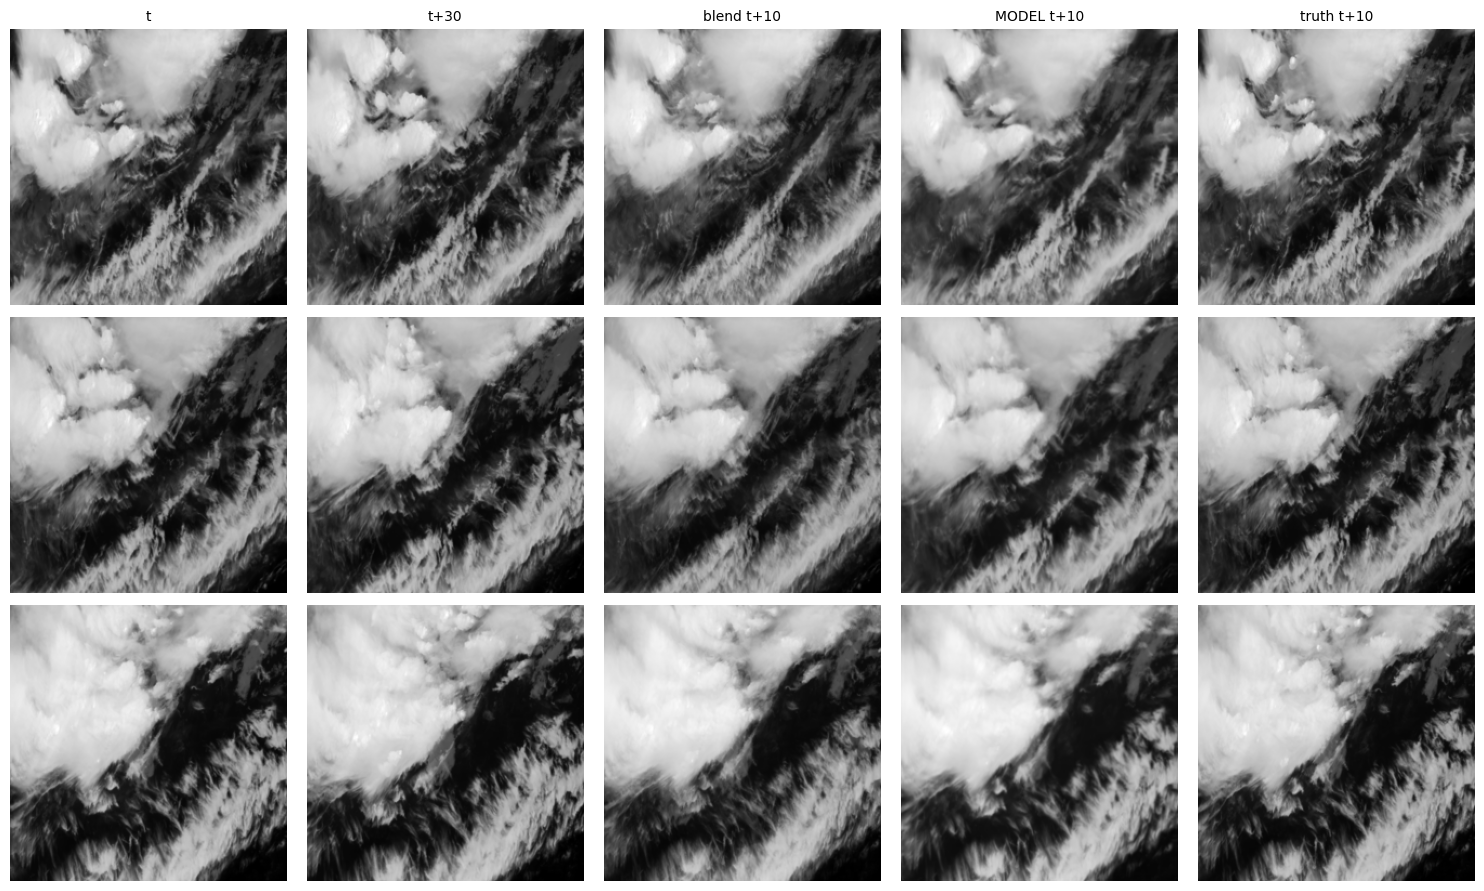

In [5]:
# ===== 4. Rigorous test: model vs baseline =====
import numpy as np, torch, matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim_fn

def eval_metrics(pred, gt):
    pred = np.clip(pred, 0, 1); gt = np.clip(gt, 0, 1)
    mse = np.mean((pred-gt)**2, axis=(1,2))
    psnr = 10*np.log10(1/np.clip(mse, 1e-12, None))
    ssim = np.array([ssim_fn(p, g, data_range=1.0) for p, g in zip(pred, gt)])
    return mse.mean(), psnr.mean(), ssim.mean()

@torch.no_grad()
def model_predict(idx, alpha):
    unet.eval(); out = np.zeros((len(idx), H, W), np.float32)
    for s in range(0, len(idx), 16):
        b = idx[s:s+16]
        X0b = torch.tensor(X0[b])[:, None].to(dev); X3b = torch.tensor(X3[b])[:, None].to(dev)
        F03b = torch.tensor(F03[b].astype(np.float32)).to(dev)
        F30b = torch.tensor(F30[b].astype(np.float32)).to(dev)
        a = torch.full((len(b), 1, 1, 1), float(alpha), device=dev)
        o, *_ = model_forward(X0b, X3b, F03b, F30b, a)
        out[s:s+16] = o[:, 0].clamp(0, 1).cpu().numpy()
    return out

b1 = (2/3)*X0 + (1/3)*X3; b2 = (1/3)*X0 + (2/3)*X3
mp1 = model_predict(val_idx, 1/3); mp2 = model_predict(val_idx, 2/3)

motion = np.mean(np.abs(X3[val_idx]-X0[val_idx]), axis=(1,2)); order = np.argsort(-motion)
hi = order[:max(1, len(order)//4)]                  # top-25% most dynamic

def show(tag, sub):
    vi = val_idx[sub]
    print(f"\n=== {tag} (n={len(vi)})            BASELINE -> MODEL ===")
    for nm, bl, mp, gt in [("t+10", b1[vi], mp1[sub], Y1[vi]),
                           ("t+20", b2[vi], mp2[sub], Y2[vi])]:
        mb = eval_metrics(bl, gt); mm = eval_metrics(mp, gt)
        print(f" {nm}  SSIM {mb[2]:.4f} -> {mm[2]:.4f} | PSNR {mb[1]:.2f} -> {mm[1]:.2f} | MSE {mb[0]:.5f} -> {mm[0]:.5f}")

show("ALL val", np.arange(len(val_idx)))
show("HIGH-MOTION val (top 25%)", hi)

# visualize the 3 most drastic cases
top = order[:3]
cols = ["t", "t+30", "blend t+10", "MODEL t+10", "truth t+10"]
fig, ax = plt.subplots(len(top), 5, figsize=(15, 3*len(top)))
for r, si in enumerate(top):
    i = val_idx[si]
    for c, (im, tt) in enumerate(zip([X0[i], X3[i], b1[i], mp1[si], Y1[i]], cols)):
        a = ax[r, c] if len(top) > 1 else ax[c]; a.imshow(im, cmap="gray_r"); a.axis("off")
        if r == 0: a.set_title(tt, fontsize=10)
plt.tight_layout(); plt.show()

## Cell 6 — Showpiece animation
Runs the trained model on full frames to build a side-by-side time-lapse: the satellite's choppy 30-minute cadence vs the AI-filled smooth 10-minute version vs the real 10-minute ground truth. Saves **advectnet_demo.gif**.

/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log
  return self.func(*new_argspec)
/usr/local/lib/python3.12/dist-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in log
  return se

saved advectnet_demo.gif


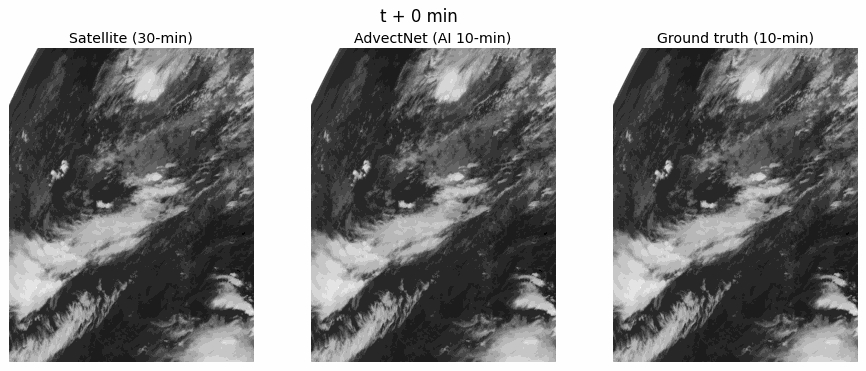

In [6]:
# ===== 5. Showpiece: choppy 30-min vs AI-interpolated vs ground truth =====
# Needs Cell 2 (load_frame) and Cell 4 (trained model) to have run.
import io, datetime as dt
import numpy as np, torch, torch.nn.functional as F
import matplotlib.pyplot as plt, imageio
from IPython.display import Image as IPImage

ANIM_START = dt.datetime(2024, 6, 15, 8, 0)   # UTC; pick an hour with active clouds

def _t(img):  return torch.tensor(img, dtype=torch.float32, device=dev)[None, None]
def _pad8(x):
    h, w = x.shape[-2:]; ph, pw = (8 - h % 8) % 8, (8 - w % 8) % 8
    return F.pad(x, (0, pw, 0, ph), mode="replicate"), (h, w)

@torch.no_grad()
def interp_full(fa, fb, alpha):
    """Interpolate a full frame at fraction alpha using the trained model."""
    unet.eval()
    a, (h, w) = _pad8(_t(fa)); b, _ = _pad8(_t(fb))
    F03, F30 = raft_flow(a, b), raft_flow(b, a)
    al = torch.full((1, 1, 1, 1), float(alpha), device=dev)
    Ft0, Ft3 = inter_flows(F03, F30, al)
    w0, w3 = backwarp(a, Ft0), backwarp(b, Ft3)
    blend = (1 - al) * a + al * b
    ach = al.expand(-1, 1, a.shape[-2], a.shape[-1])
    mask, res = unet(torch.cat([w0, w3, Ft0, Ft3, blend, ach], 1))
    out = (mask * w0 + (1 - mask) * w3 + res).clamp(0, 1)  # res = sparse source term
    return out[0, 0, :h, :w].cpu().numpy()

# load 7 consecutive real frames (t .. t+60 min)
seq = []
for k in range(7):
    f, _ = load_frame(ANIM_START + dt.timedelta(minutes=10 * k))
    seq.append(f)
hmin = min(f.shape[0] for f in seq); wmin = min(f.shape[1] for f in seq)
seq = [f[:hmin, :wmin] for f in seq]
f0, f3, f6 = seq[0], seq[3], seq[6]

# AI uses ONLY the 30-min frames (f0, f3, f6) and fills the gaps
ai = [f0, interp_full(f0, f3, 1/3), interp_full(f0, f3, 2/3),
      f3, interp_full(f3, f6, 1/3), interp_full(f3, f6, 2/3), f6]
choppy = [f0, f0, f0, f3, f3, f3, f6]    # satellite holds each 30-min frame
truth  = seq                              # real 10-min frames

labels = ["Satellite (30-min)", "AdvectNet (AI 10-min)", "Ground truth (10-min)"]
mins = [0, 10, 20, 30, 40, 50, 60]
gif = []
for k in range(7):
    fig, ax = plt.subplots(1, 3, figsize=(13, 4.8))
    for a, img, lab in zip(ax, [choppy[k], ai[k], truth[k]], labels):
        a.imshow(img, cmap="gray_r", vmin=0, vmax=1); a.set_title(lab); a.axis("off")
    fig.suptitle(f"t + {mins[k]} min", fontsize=14)
    buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=85, bbox_inches="tight")
    plt.close(fig); buf.seek(0); gif.append(imageio.imread(buf))
imageio.mimsave("advectnet_demo.gif", gif, duration=0.6, loop=0)
print("saved advectnet_demo.gif")
IPImage(filename="advectnet_demo.gif")

## Summary
This prototype proves the core idea is feasible: a warp-based, time-conditioned network reconstructs the in-between satellite frames and **beats linear interpolation, especially where clouds move**. The full AdvectNet adds physics, quadratic motion, attention and perceptual loss on top of this foundation.

*Data: Himawari-9 / JMA via NOAA Open Data on AWS. Eventual target: INSAT-3DS (MOSDAC / ISRO).*